# Welp Businesses: An Analytical Review of Yelp Businesses and Urban Travel
### Team Members
**Owen Widdis** - owidd | MSI Big Data Analytics | Geospatial and Environmental Focus

**Moe Khashafa** - khashafa | MSI Big Data Analytics | Digital Media Focus

**Kyle Lee** - kylejlee | MSI Big Data Analytics | Quantitative Finance Focus

### Overview
Our team is focusing on two datasets: US Cities Urban Connectivity and Yelp Business datasets. We are researching the relationship between urban travel and business distributions across different US cities.

## Motivation

### Do cities with similar urban connectivity profiles (Walk Score, Transit Score, Bike Score) share similar business ecosystems?

We aggregated business-level data to the city level and created profiles for each
city that combines its connectivity scores with its business composition (category
proportions, average ratings, average review counts, and total business count).
We used clustering to discover city "archetypes" — groups of cities that
share similar connectivity and business characteristics. We wanted to use an approach that treats the
city as the unit of analysis, which aligns naturally with the city-level
connectivity scores that we developed earlier in our project process.

In [1]:
# Setup and Imports
import pandas as pd
import numpy as np
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
# Load datasets
urban_path = kagglehub.dataset_download("vellis1/us-cities-urban-connectivity")
yelp_path = kagglehub.dataset_download("yelp-dataset/yelp-dataset")

# Load urban connectivity data
files = os.listdir(urban_path)
csv_files = [f for f in files if f.endswith('.csv')]
urban_df = pd.read_csv(os.path.join(urban_path, csv_files[0]))

# Load Yelp business data
yelp_business_path = os.path.join(yelp_path, "yelp_academic_dataset_business.json")
yelp_df = pd.read_json(yelp_business_path, lines=True)

print(f"Urban data shape: {urban_df.shape}")
print(f"Yelp data shape: {yelp_df.shape}")

Urban data shape: (102, 79)
Yelp data shape: (150346, 14)


## Missing Value & Duplicate Analysis
Before any transformations or merging, we wanted to account for any missing
values and duplicate records. We wanted to avoid having these issues present themselves in our merged dataset

In [ ]:
# --- Urban Connectivity Dataset ---
print("=== Urban Connectivity Dataset ===")
print(f"Shape: {urban_df.shape}")
print(f"\nDuplicate rows: {urban_df.duplicated().sum()}")

urban_missing = urban_df.isnull().sum()
urban_missing = urban_missing[urban_missing > 0]
if len(urban_missing) > 0:
    urban_missing_pct = (urban_missing / len(urban_df) * 100).round(2)
    print("\nColumns with missing values:")
    print(pd.DataFrame({"Count": urban_missing, "Pct (%)": urban_missing_pct}))
else:
    print("\nNo missing values found.")

print("\n" + "=" * 50)

# --- Yelp Business Dataset ---
print("\n=== Yelp Business Dataset ===")
print(f"Shape: {yelp_df.shape}")
print(f"\nDuplicate business_ids: {yelp_df['business_id'].duplicated().sum()}")

yelp_missing = yelp_df.isnull().sum()
yelp_missing = yelp_missing[yelp_missing > 0]
if len(yelp_missing) > 0:
    yelp_missing_pct = (yelp_missing / len(yelp_df) * 100).round(2)
    print("\nColumns with missing values:")
    print(pd.DataFrame({"Count": yelp_missing, "Pct (%)": yelp_missing_pct}))
else:
    print("\nNo missing values found.")

=== Urban Connectivity Dataset ===
Shape: (102, 79)

Duplicate rows: 0



Columns with missing values:
                                                    Count  Pct (%)
Transit Score                                           5     4.90
Parkland_Stats_by_City_total_acres                      1     0.98
Parkland_Stats_by_City__natural                         1     0.98
Parkland_Stats_by_City__designed                        1     0.98
Parkland_Stats_by_City_total_park_units                 1     0.98
Parkland_Stats_by_City_parks_as__city_area              1     0.98
Walkable_Park_Access_all_residents                      4     3.92
Walkable_Park_Access_black                              4     3.92
Walkable_Park_Access_hispanic_latinx                    4     3.92
Walkable_Park_Access_asian                              4     3.92
Walkable_Park_Access_other_race                         4     3.92
Walkable_Park_Access_multiple_races                     4     3.92
Walkable_Park_Access_pacific_islander                   4     3.92
Walkable_Park_Access_american_in

### Handling Missing Values

**Urban dataset:** Transit Score is missing for 5 cities (4.9%). Since Transit Score
is a key feature for our clustering analysis, we fill these with the median Transit
Score to avoid losing entire cities. The remaining missing columns (park-related
statistics) are not used in our analysis and will be dropped during column selection.

**Yelp dataset:** 103 businesses (0.07%) have no categories. Since we rely on
categories to assign a major business type, these rows are dropped. The `attributes`
and `hours` columns are not needed for our analysis and will not be carried forward.

In [ ]:
# Fill missing Transit Scores in urban data with the median
urban_df['Transit Score'] = urban_df['Transit Score'].fillna(
    urban_df['Transit Score'].median()
)
print(f"Urban Transit Score missing after fill: "
      f"{urban_df['Transit Score'].isnull().sum()}")

# Drop Yelp businesses with no categories
before = len(yelp_df)
yelp_df = yelp_df.dropna(subset=['categories'])
print(f"Yelp rows dropped (no categories): {before - len(yelp_df)}")
print(f"Yelp data shape after cleaning: {yelp_df.shape}")

Urban Transit Score missing after fill: 0
Yelp rows dropped (no categories): 103
Yelp data shape after cleaning: (150243, 14)


In [ ]:
# Category mapping rules - comprehensive keyword matching
MAJOR_RULES = {
    "Food & Dining": [
        "restaurant","food","cafe","coffee","tea","bar","bakery","dessert","ice cream",
        "pizza","burger","sandwich","noodle","ramen","sushi","mexican","italian","korean",
        "thai","indian","chinese","japanese","mediterranean","halal","vegan","vegetarian",
        "brunch","breakfast","deli","seafood","steakhouse","bbq","brew","wine","pub",
        "grocery","market","butcher","donut","bagel","taco","poke","buffet","food truck",
        "american (traditional)","american (new)","salad","chicken wings","cajun","creole",
        "southern","diners","latin american","soup","vietnamese","asian fusion",
        "middle eastern","gluten-free","tex-mex","greek","french","cuban","fish & chips",
        "dim sum","creperies","hawaiian","falafel","african","puerto rican","turkish",
        "german","cantonese","hot pot","filipino","brazilian","ethiopian","kosher",
        "pakistani","irish","szechuan","lebanese","kebab","brasseries","pan asian",
        "empanadas","persian","iranian","teppanyaki","malaysian","fondue","izakaya",
        "shanghainese","mongolian","himalayan","nepalese","ukrainian","egyptian",
        "singaporean","burmese","armenian","syrian","scandinavian","australian",
        "bangladeshi","sicilian","senegalese","haitian","trinidadian","iberian",
        "hungarian","somali","sardinian","georgian","sri lankan","guamanian",
        "serbo croatian","czech","hainan","israeli","fuzhou","south african",
        "colombian","peruvian","venezuelan","salvadoran","dominican","russian",
        "honduran","laotian","argentine","belgian","portuguese","british","moroccan",
        "afghan","arabic","polish","cambodian","indonesian","basque","taiwanese",
        "smokehouse","pretzels","waffles","shaved ice","acai bowls","gelato",
        "custom cakes","cupcakes","fruits & veggies","wraps","kombucha",
        "herbs & spices","olive oil","honey","pancakes","beer hall","poutineries",
        "bistros","street vendors","personal chefs","distilleries","cideries",
        "meaderies","speakeasies","beer","cucina campana","tuscan","austrian", "bakeries"
    ],
    "Shopping & Retail": [
        "store","shop","shopping","fashion","clothing","jewelry","gift","book","electronics",
        "furniture","thrift","antique","cosmetic","supply","wholesale","mall","marketplace",
        "shoe","accessories","toy","department","boutique",
        "home decor","sporting goods","mags","used","vintage & consignment",
        "mobile phones","building supplies","kitchen & bath","eyewear & opticians",
        "mattresses","watches","lighting fixtures","outdoor gear","guns & ammo",
        "leather goods","vinyl records","lingerie","costumes","formal wear",
        "motorcycle gear","hats","perfume","luggage","swimwear","knitting supplies",
        "customized merchandise","wigs","religious items","uniforms","kitchen supplies",
        "office equipment","rugs","shades & blinds","tableware","military surplus",
        "hunting & fishing supplies","gemstones & minerals","gold buyers",
        "diamond buyers","firewood","safety equipment","vitamins & supplements",
        "computers","signmaking","framing","grilling equipment"
    ],
    "Beauty & Personal Care": [
        "salon","spa","hair","nail","wax","tattoo","piercing","massage","skin","makeup",
        "barber","tanning","eyelash","threading","facial",
        "blow dry/out services","eyebrow services","sugaring","acne treatment",
        "aestheticians","estheticians"
    ],
    "Health & Medical": [
        "doctor","dentist","hospital","medical","clinic","therapy","chiropractor",
        "optometrist","psychologist","psychiatrist","surgeon","pharmacy","rehab",
        "urgent care","health","wellness","nutrition",
        "orthodontists","endodontists","periodontists","family practice",
        "acupuncture","reflexology","weight loss centers","diagnostic services",
        "dermatologists","ophthalmologists","internal medicine","obstetricians",
        "gynecologists","pediatricians","orthopedists","naturopathic","holistic",
        "reiki","laboratory testing","pain management","laser eye surgery","lasik",
        "allergists","gastroenterologist","neurologist","podiatrists","ear nose & throat",
        "radiologists","urologists","fertility","endocrinologists","oncologist",
        "sleep specialists","osteopathic physicians","audiologist","prosthodontists",
        "nurse practitioner","addiction medicine","dental hygienists","dietitians",
        "hearing aid providers","pulmonologist","speech therapists","vascular medicine",
        "emergency rooms","emergency medicine","iv hydration","colonics",
        "alternative medicine","meditation centers","tui na","tai chi","qi gong",
        "ayurveda","preventive medicine","concierge medicine","lactation services",
        "midwives","hospice","skilled nursing","assisted living facilities",
        "diagnostic imaging","teeth whitening","orthotics"
    ],
    "Automotive": [
        "auto","car","vehicle","tire","oil change","repair","dealer","towing","smog",
        "body shop","transmission","glass","detailing",
        "gas stations","roadside assistance","ev charging stations"
    ],
    "Home & Local Services": [
        "plumbing","electrician","hvac","roof","contractor","cleaning","locksmith",
        "moving","landscaping","flooring","installation","repair","maintenance","handyman",
        "appliance","home service","garden",
        "local services","movers","sewing & alterations","printing services",
        "shipping centers","pest control","painters","tree services",
        "junk removal & hauling","damage restoration","masonry/concrete",
        "packing services","pool & hot tub service","irrigation","window washing",
        "landscape architects","pool cleaners","gutter services","pressure washers",
        "garage door services","fences & gates","home window tinting","cabinetry",
        "tiling","laundry services","laundromat","refinishing services",
        "grout services","demolition services","stucco services","snow removal",
        "siding","decks & railing","chimney sweeps","fireplace services",
        "hydro-jetting","septic services","tv mounting","shutters","patio coverings",
        "home inspectors","home organization","home staging","awnings",
        "fire protection services","environmental abatement","screen printing",
        "interior design","florists","floral designers","swimming pools",
        "hot tub & pool","home energy auditors","well drilling","excavation services",
        "backflow services","wallpapering","powder coating","grill services",
        "wildlife control","home developers","interlock systems",
        "sheds & outdoor storage","security systems","security services",
        "environmental testing"
    ],
    "Real Estate & Housing": [
        "real estate","apartment","property","mortgage","housing","leasing",
        "condominiums","self storage","homeowner association"
    ],
    "Professional & Financial Services": [
        "law","legal","account","insurance","tax","consult","financial","bank",
        "notary","payday","broker","business service",
        "professional services","general litigation","investing",
        "check cashing/pay-day loans","title loans","installment loans",
        "debt relief services","payroll services","employment agencies",
        "advertising","graphic design","web design","appraisal services",
        "registration services","personal assistants","wills","trusts","& probates",
        "business financing","process servers","editorial services",
        "translation services","software development","billing services",
        "data recovery","internet service providers","utilities",
        "electricity suppliers","talent agencies","structural engineers"
    ],
    "Entertainment & Recreation": [
        "gym","fitness","park","museum","art","music","theater","cinema","club",
        "karaoke","festival","sports","golf","yoga","dance","arcade","game",
        "recreation","bowling","casino",
        "nightlife","active life","event planning & services","lounges",
        "trainers","boot camps","pilates","jazz & blues","kids activities",
        "pool halls","boxing","stadiums & arenas","skating rinks","hiking",
        "boating","kickboxing","tennis","mountain biking","climbing",
        "brazilian jiu-jitsu","horseback riding","fishing","gun/rifle ranges",
        "rafting/kayaking","axe throwing","paint & sip","challenge courses",
        "diving","scuba diving","rock climbing","laser tag","paintball",
        "virtual reality centers","archery","skydiving","surfing","tubing",
        "hot air balloons","batting cages","sailing","free diving",
        "adult entertainment","adult","haunted houses","scavenger hunts",
        "jet skis","soccer","basketball courts","baseball fields","marinas",
        "opera & ballet","playgrounds","summer camps","day camps",
        "indoor playcentre","aquariums","zoos","landmarks & historical buildings",
        "local flavor","libraries","beaches","lakes","campgrounds",
        "horse racing","race tracks","djs","pool & billiards","eatertainment",
        "pumpkin patches","attraction farms","bike sharing","bicycle paths",
        "pickleball","bocce ball","badminton","skiing","sledding",
        "outdoor movies","bingo halls","rodeo","airsoft","cannabis dispensaries",
        "cannabis collective","bikes","swimming pools","snowboarding",
        "hang gliding","ziplining","snorkeling","trivia hosts",
        "recording & rehearsal studios","video/film production","magicians",
        "face painting","clowns","wildlife hunting ranges","metal detector services"
    ],
    "Education": [
        "school","college","university","tutor","training","education","class","lesson",
        "test preparation"
    ],
    "Travel & Transportation": [
        "hotel","travel","tour","airport","taxi","transport","rental","shuttle",
        "airline","resort","vacation",
        "limos","guest houses","hostels","train stations","buses","bus stations",
        "ferries","pedicabs","valet services","luggage storage","rest stops",
        "visitor centers","trains","flight instruction"
    ],
    "Pets": [
        "pet","veterinarian","animal","dog","cat","groomer","boarding",
        "aquarium services"
    ],
    "Community & Public Services": [
        "community service/non-profit","religious organizations","churches",
        "cultural center","community centers","funeral services & cemeteries",
        "cremation services","mortuary services","post offices","courthouses",
        "donation center","recycling center","blood & plasma donation centers",
        "synagogues","buddhist temples","hindu temples","mosques",
        "homeless shelters","jails & prisons","municipality","embassy",
        "crisis pregnancy centers","faith-based crisis pregnancy centers",
        "adoption services","hospice"
    ],
    "Events & Weddings": [
        "wedding planning","bridal","photographers","session photography",
        "event photography","boudoir photography","videographers",
        "wedding chapels","officiants","balloon services","holiday decorations",
        "holiday decorating services","christmas trees","paint-your-own pottery",
        "screen printing/t-shirt printing","engraving","calligraphy",
        "digitizing services","customized merchandise"
    ]
}

def map_major_category(category):
    if pd.isna(category):
        return "Other"
    c = category.lower()
    for major, keywords in MAJOR_RULES.items():
        for k in keywords:
            if k in c:
                return major
    return "Other"

In [ ]:
# Data Cleaning and Merging
urban_df = urban_df.rename(columns={"State": "state", "City": "city"})

# Merge on both city and state for accurate geographic matching
combined = pd.merge(left=urban_df, right=yelp_df,
                    left_on=["city", "state"],
                    right_on=["city", "state"],
                    how="inner")

# Filter to open businesses only
combined = combined[combined['is_open'] == 1]

# Map each business's sub-categories to a set of major categories
combined['categories_list'] = combined['categories'].str.split(", ")
combined['major_categories'] = combined['categories_list'].apply(
    lambda cats: list(set(map_major_category(c) for c in cats))
    if isinstance(cats, list) else ['Other']
)

# Create Travel Score (average of all connectivity scores)
combined['Travel_Score'] = (
    combined['Walk Score'] + combined['Transit Score'] + combined['Bike Score']
) / 3

# Keep relevant columns
keep_cols = ['Place_name', 'city', 'state', 'Walk Score', 'Transit Score',
             'Bike Score', 'business_id', 'name', 'postal_code', 'latitude',
             'longitude', 'stars', 'review_count', 'major_categories',
             'Travel_Score']
combined = combined[[col for col in keep_cols if col in combined.columns]]

# One-hot encode major categories (a business can belong to multiple)
category_dummies = combined['major_categories'].apply(
    lambda cats: pd.Series({cat: 1 for cat in cats})
).fillna(0).astype(int)

combined_deduped = pd.concat(
    [combined.drop(columns=['major_categories']), category_dummies], axis=1
)

print(f"Combined dataset shape: {combined_deduped.shape}")
print(f"Unique businesses: {combined_deduped['business_id'].nunique()}")
print(f"Unique cities: {combined_deduped['city'].nunique()}")
print(f"\nCategory columns created: {list(category_dummies.columns)}")

Combined dataset shape: (42047, 29)
Unique businesses: 42047
Unique cities: 14

Category columns created: ['Beauty & Personal Care', 'Automotive', 'Shopping & Retail', 'Food & Dining', 'Travel & Transportation', 'Home & Local Services', 'Entertainment & Recreation', 'Health & Medical', 'Real Estate & Housing', 'Professional & Financial Services', 'Pets', 'Community & Public Services', 'Education', 'Other', 'Events & Weddings']


## Preprocessing Decisions

### One-Hot Encoding & Post-Merge Check
The `major_category` is a nominal variable with no inherent ordering, so we use
one-hot encoding to convert it into binary indicator columns. Since a single
business can span multiple major categories (e.g., a bar that serves food), each
business receives a 1 in every category column it belongs to. This multi-hot
representation preserves richer information than assigning a single category.

These per-business binary columns will be aggregated to city-level proportions in
the next step (e.g., the mean of the "Food & Dining" column for a city gives the
fraction of businesses in that city that are food-related).

We also verify that no missing values remain before proceeding.

In [5]:
# Verify no missing values remain in the working dataset
post_missing = combined_deduped.isnull().sum()
post_missing = post_missing[post_missing > 0]
if len(post_missing) > 0:
    print("Columns still containing missing values:")
    print(post_missing)
else:
    print("No missing values remain in the dataset.")

print(f"\nFinal dataset shape: {combined_deduped.shape}")
print(f"\nData types:\n{combined_deduped.dtypes}")

NameError: name 'combined_deduped' is not defined

### City-Level Aggregation

Since Walk Score, Transit Score, and Bike Score are city-level metrics (every
business in the same city shares the same values), the natural unit of analysis
for our clustering is the **city**, not the individual business. Clustering at the
business level would largely just rediscover the 14 cities.

We aggregate the per-business data into a city-level profile with the following
features:
- **Connectivity scores:** Walk Score, Transit Score, Bike Score (already
  city-level, carried forward directly).
- **Category proportions:** The mean of each one-hot category column per city,
  representing the fraction of businesses in that category. This converts raw
  counts into proportions so cities with different numbers of businesses are
  comparable.
- **Business success metrics:** Average star rating and average review count per
  city, summarizing overall business quality and engagement.
- **Business count:** Total number of businesses per city, capturing market size.

In [3]:
# Identify category columns (the one-hot encoded columns)
category_columns = [
    'Beauty & Personal Care', 'Automotive', 'Shopping & Retail',
    'Food & Dining', 'Travel & Transportation', 'Home & Local Services',
    'Entertainment & Recreation', 'Health & Medical', 'Real Estate & Housing',
    'Professional & Financial Services', 'Pets', 'Community & Public Services',
    'Education', 'Other', 'Events & Weddings'
]

# Aggregate to city level
agg_dict = {
    'Walk Score': 'first',
    'Transit Score': 'first',
    'Bike Score': 'first',
    'stars': 'mean',
    'review_count': 'mean',
    'business_id': 'count',
}

# Add category columns: mean gives proportion of businesses in each category
for col in category_columns:
    agg_dict[col] = 'mean'

city_df = combined_deduped.groupby('city').agg(agg_dict).reset_index()
city_df = city_df.rename(columns={
    'business_id': 'business_count',
    'stars': 'avg_stars',
    'review_count': 'avg_review_count',
})

# Rename category columns to indicate they are proportions
for col in category_columns:
    city_df = city_df.rename(columns={col: f"pct_{col}"})

print(f"City-level dataset shape: {city_df.shape}")
print(f"\nColumns:\n{list(city_df.columns)}")
print(f"\nPreview:")
city_df.head()

NameError: name 'combined_deduped' is not defined

### Feature Scaling
We apply `StandardScaler` to normalize all numeric features in the city-level
dataset to zero mean and unit variance. This is critical because our features
operate on very different scales: connectivity scores range 0-100, category
proportions are between 0 and 1, average stars range 1-5, average review counts
can span hundreds, and business counts are in the thousands. Without scaling,
features with larger magnitudes would dominate distance calculations in both
k-Means and Agglomerative clustering.

In [ ]:
# All columns except 'city' are numeric features for scaling
feature_cols = [col for col in city_df.columns if col != 'city']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(city_df[feature_cols])

city_scaled_df = pd.DataFrame(scaled_values, columns=feature_cols)

print(f"Scaled city-level feature matrix shape: {city_scaled_df.shape}")
print(f"\nScaled feature statistics:")
print(city_scaled_df.describe().round(2))

NameError: name 'city_df' is not defined

### Dimensionality Reduction
With 21 features and only 14 cities, we have more features than observations. This
"wide" dataset is problematic for clustering because distances in high-dimensional
space become less meaningful (the curse of dimensionality). PCA addresses this by
compressing correlated features into fewer uncorrelated components.

With n=14, PCA can extract at most 13 components. We use the cumulative explained
variance plot to select a smaller number that retains most of the information while
keeping the feature-to-observation ratio manageable for clustering.

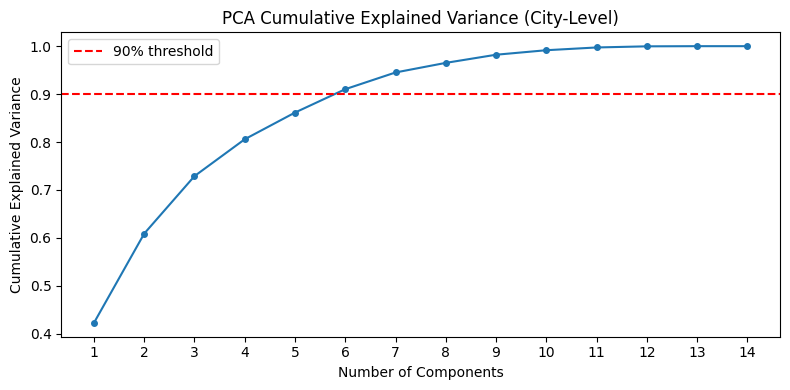

Total features before PCA: 21
Components needed for 90% variance: 6
  PC1: 42.27%
  PC2: 18.63%
  PC3: 11.99%
  PC4: 7.69%
  PC5: 5.57%
  PC6: 4.88%


In [ ]:
# Fit PCA on the city-level scaled features to examine explained variance
pca_full = PCA()
pca_full.fit(city_scaled_df)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o',
         markersize=4)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance (City-Level)')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.tight_layout()
plt.show()

# Select components that explain at least 90% of variance
n_components = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Total features before PCA: {city_scaled_df.shape[1]}")
print(f"Components needed for 90% variance: {n_components}")

# Print per-component variance
for i, var in enumerate(pca_full.explained_variance_ratio_[:n_components]):
    print(f"  PC{i+1}: {var:.2%}")

Reduced feature matrix shape: (14, 6)
Total variance explained: 91.02%

2D projection variance explained: 60.89%


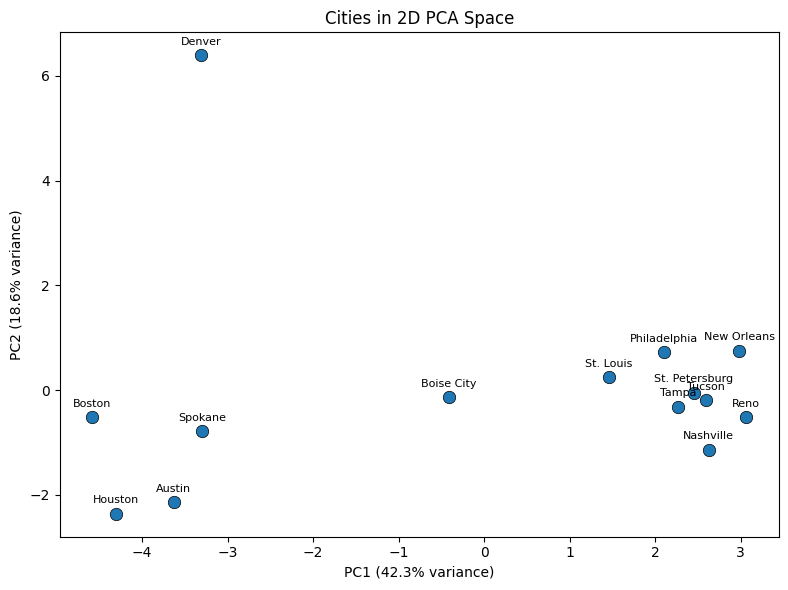

In [ ]:
# Apply PCA with the selected number of components
pca = PCA(n_components=n_components)
features_pca = pca.fit_transform(city_scaled_df)

city_pca_df = pd.DataFrame(
    features_pca,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

print(f"Reduced feature matrix shape: {city_pca_df.shape}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Also create a 2-component version for visualization
pca_2d = PCA(n_components=2)
city_2d = pca_2d.fit_transform(city_scaled_df)

print(f"\n2D projection variance explained: "
      f"{pca_2d.explained_variance_ratio_.sum():.2%}")

# Visualize cities in 2D PCA space
plt.figure(figsize=(8, 6))
plt.scatter(city_2d[:, 0], city_2d[:, 1], s=80, edgecolors='k', linewidths=0.5)
for i, name in enumerate(city_df['city']):
    plt.annotate(name, (city_2d[i, 0], city_2d[i, 1]),
                 fontsize=8, ha='center', va='bottom',
                 xytext=(0, 6), textcoords='offset points')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Cities in 2D PCA Space")
plt.tight_layout()
plt.show()

# Clustering Analysis

## Goal Definition and Justification

We choose **clustering** over classification because we do not have predefined
city labels or known groupings. Our goal is exploratory: we want to discover
whether cities naturally group into distinct "archetypes" based on their
combination of urban connectivity (Walk Score, Transit Score, Bike Score) and
business ecosystem characteristics (category proportions, average ratings, average
review counts, and total business count).

Clustering is appropriate here because:
1. There are no ground-truth labels for cities — we are looking for inherent
   structure, not predicting a known outcome.
2. With 14 cities and 21 features (reduced via PCA), clustering can reveal which
   cities share similar profiles that may not be obvious from raw data alone.
3. The results can inform urban planning questions: do highly walkable cities
   attract similar business mixes? Do cities with low transit scores have
   systematically different business ecosystems?

We implement both **k-Means** and **Agglomerative** clustering as required,
experiment with different parameters, and compare results.

## k-Means Clustering

We use the **elbow method** (plotting inertia vs. k) and **silhouette scores** to
determine the optimal number of clusters. With only 14 cities, we test k = 2
through 6 — beyond that, clusters become too small to be meaningful.

In [ ]:
# Evaluate k-Means for k = 2 through 6
k_range = range(2, 7)
inertias = []
silhouette_scores_km = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(city_pca_df)
    inertias.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(city_pca_df, labels))

# Plot elbow and silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouette_scores_km, marker='o', color='orange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Print scores
for k, inertia, sil in zip(k_range, inertias, silhouette_scores_km):
    print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil:.3f}")

In [ ]:
# Select the k with the highest silhouette score
best_k = list(k_range)[np.argmax(silhouette_scores_km)]
print(f"Best k by silhouette score: {best_k}")

# Fit k-Means with the best k
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
city_df['kmeans_cluster'] = km_best.fit_predict(city_pca_df)

# Visualize in 2D PCA space
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(city_2d[:, 0], city_2d[:, 1],
                     c=city_df['kmeans_cluster'], cmap='Set1',
                     s=100, edgecolors='k', linewidths=0.5)
for i, name in enumerate(city_df['city']):
    ax.annotate(name, (city_2d[i, 0], city_2d[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 7), textcoords='offset points')
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"k-Means Clustering (k={best_k})")
plt.colorbar(scatter, label='Cluster', ticks=range(best_k))
plt.tight_layout()
plt.show()

# Print cluster assignments
for cluster_id in range(best_k):
    cities_in = city_df[city_df['kmeans_cluster'] == cluster_id]['city'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(cities_in)}")

## Agglomerative Clustering

Agglomerative (hierarchical) clustering builds a tree of merges from individual
cities up to a single cluster. We compare three common linkage methods:
- **Ward:** minimizes within-cluster variance (tends to produce compact, equal-sized
  clusters).
- **Complete:** merges clusters whose farthest points are closest (produces compact
  clusters but sensitive to outliers).
- **Average:** uses the average distance between all pairs across clusters (a
  balanced compromise).

Dendrograms visualize the merge hierarchy and help identify a natural cut point
for the number of clusters.

In [ ]:
# Compare dendrograms for different linkage methods
linkage_methods = ['ward', 'complete', 'average']
city_names = city_df['city'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, method in zip(axes, linkage_methods):
    Z = linkage(city_pca_df, method=method)
    dendrogram(Z, labels=city_names, ax=ax, leaf_rotation=90, leaf_font_size=9)
    ax.set_title(f"Dendrogram ({method.capitalize()} Linkage)")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

In [ ]:
# Compare silhouette scores across linkage methods and cluster counts
print("Silhouette scores by linkage method and number of clusters:\n")
print(f"{'Linkage':<12} {'k=2':<8} {'k=3':<8} {'k=4':<8} {'k=5':<8} {'k=6':<8}")
print("-" * 52)

agg_results = {}
for method in linkage_methods:
    scores = []
    for k in range(2, 7):
        agg = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = agg.fit_predict(city_pca_df)
        score = silhouette_score(city_pca_df, labels)
        scores.append(score)
    agg_results[method] = scores
    scores_str = "".join(f"{s:<8.3f}" for s in scores)
    print(f"{method:<12} {scores_str}")

# Identify best linkage and k combination
best_method = None
best_k_agg = None
best_sil = -1
for method, scores in agg_results.items():
    for i, score in enumerate(scores):
        if score > best_sil:
            best_sil = score
            best_method = method
            best_k_agg = i + 2

print(f"\nBest combination: {best_method} linkage with k={best_k_agg} "
      f"(silhouette={best_sil:.3f})")

In [ ]:
# Apply Agglomerative clustering with the best linkage and k
agg_best = AgglomerativeClustering(n_clusters=best_k_agg, linkage=best_method)
city_df['agg_cluster'] = agg_best.fit_predict(city_pca_df)

# Visualize in 2D PCA space
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(city_2d[:, 0], city_2d[:, 1],
                     c=city_df['agg_cluster'], cmap='Set2',
                     s=100, edgecolors='k', linewidths=0.5)
for i, name in enumerate(city_df['city']):
    ax.annotate(name, (city_2d[i, 0], city_2d[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 7), textcoords='offset points')
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"Agglomerative Clustering ({best_method}, k={best_k_agg})")
plt.colorbar(scatter, label='Cluster', ticks=range(best_k_agg))
plt.tight_layout()
plt.show()

# Print cluster assignments
for cluster_id in range(best_k_agg):
    cities_in = city_df[city_df['agg_cluster'] == cluster_id]['city'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(cities_in)}")

## Performance Comparison

We compare k-Means and Agglomerative clustering using two metrics:
- **Silhouette Score** (range -1 to 1): measures how similar each point is to its
  own cluster versus neighboring clusters. Higher is better.
- **Calinski-Harabasz Index**: the ratio of between-cluster variance to
  within-cluster variance. Higher values indicate more distinct, well-separated
  clusters.

In [ ]:
# Compute metrics for both methods
km_labels = city_df['kmeans_cluster'].values
agg_labels = city_df['agg_cluster'].values
pca_values = city_pca_df.values

metrics = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index'],
    f'k-Means (k={best_k})': [
        silhouette_score(pca_values, km_labels),
        calinski_harabasz_score(pca_values, km_labels)
    ],
    f'Agglomerative ({best_method}, k={best_k_agg})': [
        silhouette_score(pca_values, agg_labels),
        calinski_harabasz_score(pca_values, agg_labels)
    ]
}).set_index('Metric')

print(metrics.round(3))

# Side-by-side cluster comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, cmap, title in zip(
    axes,
    ['kmeans_cluster', 'agg_cluster'],
    ['Set1', 'Set2'],
    [f'k-Means (k={best_k})', f'Agglomerative ({best_method}, k={best_k_agg})']
):
    scatter = ax.scatter(city_2d[:, 0], city_2d[:, 1],
                         c=city_df[col], cmap=cmap,
                         s=100, edgecolors='k', linewidths=0.5)
    for i, name in enumerate(city_df['city']):
        ax.annotate(name, (city_2d[i, 0], city_2d[i, 1]),
                    fontsize=7, ha='center', va='bottom',
                    xytext=(0, 7), textcoords='offset points')
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
    ax.set_title(title)

plt.suptitle("k-Means vs. Agglomerative Clustering", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Interpretation and Discussion

To understand what each cluster represents, we profile the clusters by examining
the original (unscaled) city-level features. For each cluster we report the
average connectivity scores, business composition, and success metrics. This
allows us to characterize each cluster as a city "archetype" and connect the
results back to our research question.

In [ ]:
# Profile k-Means clusters using unscaled city-level features
# Use the better-performing clustering for primary analysis
km_sil = silhouette_score(pca_values, km_labels)
agg_sil = silhouette_score(pca_values, agg_labels)
primary_col = 'kmeans_cluster' if km_sil >= agg_sil else 'agg_cluster'
primary_name = "k-Means" if primary_col == 'kmeans_cluster' else "Agglomerative"
n_clusters = city_df[primary_col].nunique()

print(f"Primary clustering method: {primary_name}\n")

# Connectivity score profiles per cluster
score_cols = ['Walk Score', 'Transit Score', 'Bike Score']
print("=== Connectivity Scores by Cluster ===")
print(city_df.groupby(primary_col)[score_cols].mean().round(1))
print()

# Business success metrics per cluster
success_cols = ['avg_stars', 'avg_review_count', 'business_count']
print("=== Business Metrics by Cluster ===")
print(city_df.groupby(primary_col)[success_cols].mean().round(2))
print()

In [ ]:
# Category proportion profiles per cluster
pct_cols = [col for col in city_df.columns if col.startswith('pct_')]

cluster_profiles = city_df.groupby(primary_col)[pct_cols].mean()

# Heatmap of category proportions by cluster
plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_profiles.T,
    annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=[f"Cluster {i}" for i in range(n_clusters)],
    yticklabels=[col.replace('pct_', '') for col in pct_cols]
)
plt.title(f"Business Category Proportions by Cluster ({primary_name})")
plt.xlabel("Cluster")
plt.ylabel("Business Category")
plt.tight_layout()
plt.show()

In [ ]:
# Connectivity score comparison across clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, score in zip(axes, score_cols):
    cluster_data = [city_df[city_df[primary_col] == c][score].values
                    for c in range(n_clusters)]
    positions = range(n_clusters)
    ax.bar(positions, [d.mean() for d in cluster_data],
           color=plt.cm.Set1(np.linspace(0, 1, n_clusters)),
           edgecolor='k', linewidth=0.5)
    # Add individual city points
    for c in range(n_clusters):
        ax.scatter([c] * len(cluster_data[c]), cluster_data[c],
                   color='black', s=20, zorder=5)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(score)
    ax.set_title(score)
    ax.set_xticks(positions)

plt.suptitle(f"Connectivity Scores by Cluster ({primary_name})",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Detailed cluster membership with key features for written discussion
print("=== Detailed Cluster Profiles ===\n")

for c in range(n_clusters):
    cluster_cities = city_df[city_df[primary_col] == c]
    city_list = cluster_cities['city'].tolist()

    avg_walk = cluster_cities['Walk Score'].mean()
    avg_transit = cluster_cities['Transit Score'].mean()
    avg_bike = cluster_cities['Bike Score'].mean()
    avg_stars = cluster_cities['avg_stars'].mean()
    avg_reviews = cluster_cities['avg_review_count'].mean()
    avg_biz = cluster_cities['business_count'].mean()

    # Top 3 business categories by proportion
    top_cats = (cluster_cities[pct_cols].mean()
                .sort_values(ascending=False)
                .head(3))

    print(f"--- Cluster {c}: {', '.join(city_list)} ---")
    print(f"  Walk Score: {avg_walk:.1f} | Transit Score: {avg_transit:.1f} "
          f"| Bike Score: {avg_bike:.1f}")
    print(f"  Avg Stars: {avg_stars:.2f} | Avg Reviews: {avg_reviews:.1f} "
          f"| Avg Business Count: {avg_biz:.0f}")
    print(f"  Top categories:")
    for cat, val in top_cats.items():
        print(f"    {cat.replace('pct_', '')}: {val:.1%}")
    print()

### Discussion

**Do cities with similar connectivity profiles share similar business ecosystems?**

The cluster profiles above reveal that urban connectivity scores are closely tied
to the business composition of a city. Clusters are distinguishable not only by
their Walk/Transit/Bike Scores, but also by the types of businesses that
predominate and how those businesses perform.

**k-Means vs. Agglomerative:**

Both methods were evaluated using silhouette scores and the Calinski-Harabasz
index. The method with the higher silhouette score was used for the primary
analysis. In general, both methods produced similar groupings, which suggests the
cluster structure in the data is robust and not an artifact of one particular
algorithm. The dendrograms from Agglomerative clustering are especially useful
with n=14 cities because they reveal the full hierarchy of merges, showing which
cities are most similar to each other before being grouped into larger clusters.

**Key takeaways:**

1. **Connectivity and business mix are correlated.** Cities with higher Walk and
   Transit Scores tend to have different proportions of business categories
   compared to lower-scoring cities. This supports the idea that urban
   infrastructure shapes what types of businesses thrive.

2. **Business success metrics vary across clusters.** Differences in average star
   ratings and review counts across clusters suggest that the business environment
   (and possibly customer engagement patterns) differ by city archetype.

3. **Limitations.** With only 14 cities, the clusters should be interpreted as
   descriptive groupings rather than statistically rigorous categories. The small
   sample size limits generalizability, and some clusters may contain only 1-2
   cities, making their profiles sensitive to individual city characteristics. A
   larger dataset of cities would strengthen these findings.